# 1. Carga de Datos XLSX a Pandas Dataframe

Para realizar el analsis de datos, primero cargaremos todos los datos de forma 'cruda', es decir, sin aplicar ningun filtro. Tras esto se realizará la limpieza de datos correspondiente para eliminar filas incompletas o columnas que no aporten información. La información que se obtenga de los datos en el analisis o limpieza será muy util a la hora de crear la base de datos y evitar insertar tuplas incorrectas o incompletas.

In [1]:
import pandas as pd
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from matplotlib.patches import Patch

In [2]:
# Función para poner todas las fechas en el mismo formato: 'YYYY-MM-DD'
def normalize_dates(date_list):
    output_list = []
    dt = None
    year = None
    month = None
    for date in date_list:
        try:
            # Algunas de las fechas tienen espacios, los eliminamos
            date = date.replace(" ", "")
            
            #El año siempre viene defnido por los 4 ultimos caracteres y el mes por los 2 anteriores al año
            # Algunos de los dias vienen no definidos excatemente (ej: 17_19022020), nos quedamos con el último dia del rango por comodidad
            year = date[-4:]
            month = date[-6:-4]
            day = date[-8:-6]
            
            # Creamos un datetime y lo formateamos a YYYY-MM-DD (nos vendrá bien este formato para insertar en la base de datos)
            dt = datetime(int(year), int(month), int(day))
            output_list.append(dt.strftime("%Y-%m-%d"))
        except Exception as e:
            print(f"\nError: {e}")
            print(f"Nombre de página incorrecto: {date_list[0]}, por favor corrija el nombre al formato DDMMYYYY en el archivo y pruebe de nuevo")
        
    return output_list


# Ignoramos las paginas que no tengan el nombre en formato DDMMYYYY
def sheet_is_valid(sheet_name):
    return not len(sheet_name) < 8 # hay hojas que no mantienen la estructura de datos y no tienen informacion, solo añaden ruido y distorsionan la estructura (ej: excel 2599_)

In [3]:
# ------------------------------------ALGORITMO DE CRAECIÓN DEL DATAFRAME TOTAL-------------------------------------------------

# Carpeta con todos los excels menos 'otros puntos'
excels_dir = "../Datos Excel/LecturasIncluidas"
excel_counter = 0
df_list = []

for excel_name in os.listdir(excels_dir):
    # Obtenemos la ubicación del excel
    excel_full_dir = os.path.join(excels_dir, str(excel_name))
    
    # Obtenemos el excel
    excel = pd.ExcelFile(excel_full_dir)
    
    # Contamos cuantas paginas tiene el xlsx
    number_sheets = len(excel.sheet_names)
    
    print(f"\n ({excel_counter+1}/{len(os.listdir(excels_dir))}) Cargando archivo: {excel_name} | Numero Páginas totales: {number_sheets}")
    excel_counter+=1
    
    # Iteramos por todas las paginas del xlsx para sacar todos los dataframes en una lista
    for i in range(0,number_sheets):
        
        # Si la hoja no tiene los datos que queremos se pasa a la siguiente iteración
        if not sheet_is_valid(excel.sheet_names[i]):
            continue
        
        print(f"\r\t\t Pag {i+1}", end="")
        # Cargamos la pagina en un dataframe
        # skiprows hace que no carguemos las 3 primeras filas de la pagina en el dataframe (en esas filas solo está la fecha)
        # usecols hace que solo leamos las 7 primeras columnas, ya que hay la sheet 18062018 del fichero 2575 tiene una columna extra que se lee y se añade erroneamente como columna
        df_sheet = pd.read_excel(excel_full_dir, sheet_name=i, skiprows=range(3), usecols=range(7))
        
        if str(excel.sheet_names[i]) == "020142019":
            sheet_date = normalize_dates(["02042019"])[0]
        else:
            sheet_date = normalize_dates([excel.sheet_names[i]])[0]
        
        # Añadimos la columna de fecha al datafranme y ponemos todos sus valores a la fecha obtenida anteriormente
        df_sheet.insert(7, "Date", "")
        df_sheet['Date'] = sheet_date
        
        '''# Añadimos la columna grupo con todos sus valores NaN por el momento
        df_sheet.insert(8, "Group", "")
        df_sheet['Group'] = pd.NA'''
        
        # Añadimos el dataframe modificado a la lista
        df_list.append(df_sheet)

# Unificamos todos los dataframes en uno, ignore_index hace que se cree un nuevo indice para cada fila, haciendolos únicos
df_muestras = pd.concat(df_list, ignore_index=True)
df_muestras


 (1/19) Cargando archivo: 2554_RESULTADOS CUALITATIVOS PE╠üTROLA 2018_2023.xlsx | Numero Páginas totales: 22
		 Pag 22
 (2/19) Cargando archivo: 2571_RESULTADOS CUALITATIVOS PE╠üTROLA 2018_2023 .xlsx | Numero Páginas totales: 22
		 Pag 22
 (3/19) Cargando archivo: 2575_RESULTADOS CUALITATIVOS PE╠üTROLA 2018_2023.xlsx | Numero Páginas totales: 22
		 Pag 22
 (4/19) Cargando archivo: 2599_RESULTADOS CUALITATIVOS PE╠üTROLA 2018_2023.xlsx | Numero Páginas totales: 17
		 Pag 3
 (5/19) Cargando archivo: 2602_RESULTADOS CUALITATIVOS PE╠üTROLA 2018_2023.xlsx | Numero Páginas totales: 19
		 Pag 18
 (6/19) Cargando archivo: 2635_RESULTADOS CUALITATIVOS PE╠üTROLA 2018_2023.xlsx | Numero Páginas totales: 19
		 Pag 19
 (7/19) Cargando archivo: 2640_RESULTADOS CUALITATIVOS PE╠üTROLA 2018_2023.xlsx | Numero Páginas totales: 22
		 Pag 22
 (8/19) Cargando archivo: 2641_RESULTADOS CUALITATIVOS PE╠üTROLA 2018_2023.xlsx | Numero Páginas totales: 22
		 Pag 22
 (9/19) Cargando archivo: 2642_RESULTADOS CUALI

,Component RT,Library RT,Compound Name,Match Factor,Formula,CAS#,Sample Name,Date
0,22.446411,NaN,Octacosane,97.344876,C28H58,630-02-4,2554_070318_FS_SV,2018-03-17
1,8.457277,NaN,"Benzenesulfonamide, N-butyl-",97.342626,C10H15NO2S,3622-84-2,2554_070318_FS_SV,2018-03-17
2,6.200755,NaN,Dodecanoic acid,97.034088,C12H24O2,143-07-7,2554_070318_FS_SV,2018-03-17
3,6.553432,9.958,Diethyl phthalate,96.880089,C12H14O4,84-66-2,2554_070318_FS_SV,2018-03-17
4,13.224109,NaN,Octadecanoic acid,96.826412,C18H36O2,57-11-4,2554_070318_FS_SV,2018-03-17
...,...,...,...,...,...,...,...,...
92895,11.813947,NaN,Allyl p-(2-hydroxyethoxy)benzoate,70.356172,C12H14O4,1000241-83-5,GW38_13_10_2020_SCAN,2020-11-17
92896,14.399062,NaN,3-Ethyl-3-methylheptane,70.297500,C10H22,17302-01-1,GW38_13_10_2020_SCAN,2020-11-17
92897,15.874923,NaN,"Thiourea, 1-benzoyl-3-(3-methyl-5-isoxazolyl)-",70.122934,C12H11N3O2S,118385-15-2,GW38_13_10_2020_SCAN,2020-11-17
92898,14.682249,NaN,"Tricyclo[3.3.1.1(3,7)]decanone, 4-iodo-, (1.al...",70.103971,C10H13IO,56781-85-2,GW38_13_10_2020_SCAN,2020-11-17


In [4]:
# Carpeta con el excel de las estaciones
station_excel_dir = "../Datos Excel/Estaciones/General_completo.xlsx"
df_stations = pd.read_excel(pd.ExcelFile(station_excel_dir))
df_stations

,StationID,TIPO,Geology,Well_Depth,Elevation,X,Y,OBSERVACIONES,Nivelation,Litofreno,...,Fecha ejecución,NºITGE,Ensayo de bombeo,Caracteristicas técnicas,Niveles piezométricos,Litología,Analisis Químicos,Datos bomba,TITULAR,TELEFONO
0,493,1,JURÁSICO,400.00,910.00,628525.0,4302550,Sacado de base de datos de David Sanz.Balsa de...,0.0,0.0,...,NaT,NaN,0.0,0.0,1.0,0.0,0.0,1.0,Agustín Jiménez Millán (Encargado),630347182
1,699,1,JURÁSICO,200.00,844.14,619500.0,4300650,CHINCHILLA DE MONTE ARAGON,0.0,0.0,...,NaT,NaN,0.0,1.0,1.0,1.0,0.0,0.0,JJ.CC CASTILLA LA MANCHA,NaN
2,2429,1,JURÁSICO,215.00,891.00,631340.0,4300490,NaN,0.0,0.0,...,1971-01-01,0.0,0.0,1.0,1.0,1.0,0.0,0.0,NaN,NaN
3,2430,1,JURÁSICO,108.36,850.00,619644.0,4300550,NaN,0.0,0.0,...,1971-01-01,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN
4,2534,1,CRETÁCICO,30.00,900.00,622443.0,4300541,¿Explota Jurásico?,0.0,0.0,...,NaT,0.0,0.0,0.0,1.0,1.0,1.0,0.0,IVAN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,2652,2,CRETÁCICO,NaN,NaN,623769.0,4300518,NaN,NaN,NaN,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,GW12,0,NaN,NaN,NaN,624930.0,4299677,NaN,NaN,NaN,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,GW34,0,NaN,NaN,NaN,624936.0,4299677,NaN,NaN,NaN,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107,GW26,0,NaN,NaN,NaN,624919.0,4299677,NaN,NaN,NaN,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
# 2. Limpieza de datos

## 2.1 Estudio y eliminación de atributos que no aportan información

Realizaremos un estudio de la importancia de cada uno de los atributos de muestras y estaciones para saber cuales incluiremos en el analisis y cuales no. Los factores relevantes para tomar la decisión serán:
* Relevancia de la variable para un analisis computacional: Algunas variables pueden no ser computables, como por ejemplo las observaciones.
* Informacón aportada: Si la mayoria de la información de una variable es None o todos sus valores son el mismo, se descarta porque no aportan información y no se podran sacar patrones relevantes de ellas.
* Confidencialidad: Si algunas de las variables contienen información personal, como nombres, documentos de identidad o numeros de telefono se descaratan ya que aparte de no aportar información, podriamos causar una fuga de seguridad.
* Tipo de dato: Algunos datos como imagenes o referencias a otras tablas que no tenemos no serán de utilidad para nuestro analisis

<br>

### 2.1.1. Estudio de variables potencialmente inutiles en df_muestras
Como vemos las 8 variables de df_muestras tienen muchos valores diferentes y muy pocas NaN, por lo que en principio tienen potencial para ser variables que nos aporten bastante información.

In [5]:
df_muestras.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92900 entries, 0 to 92899
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Component RT   92900 non-null  float64
 1   Library RT     3193 non-null   float64
 2   Compound Name  92900 non-null  object 
 3   Match Factor   92900 non-null  float64
 4   Formula        92900 non-null  object 
 5   CAS#           92900 non-null  object 
 6   Sample Name    92900 non-null  object 
 7   Date           92900 non-null  object 
dtypes: float64(3), object(5)
memory usage: 5.7+ MB


In [6]:
for col in df_muestras.columns:
    print(f"--- Frecuencia de valores en '{col}' ---")
    print(df_muestras[col].value_counts(dropna=False))
    print("\n")

--- Frecuencia de valores en 'Component RT' ---
Component RT
13.002619    4
19.391538    4
9.512695     4
9.564972     2
16.526448    2
            ..
9.289463     1
9.204616     1
29.838737    1
16.468622    1
10.671870    1
Name: count, Length: 91384, dtype: int64


--- Frecuencia de valores en 'Library RT' ---
Library RT
NaN          89707
33.962000      285
18.415000      279
15.895000      232
9.958000       207
             ...  
29.254283        1
8.968000         1
21.795000        1
4.571042         1
4.885517         1
Name: count, Length: 134, dtype: int64


--- Frecuencia de valores en 'Compound Name' ---
Compound Name
1-Decanol, 2-hexyl-                                                                                    3419
Dodecane, 1-iodo-                                                                                      2637
Heneicosane                                                                                            2443
Cyclononasiloxane, octadecamethyl-   

### 2.1.2. Estudio de variables potencialmente inutiles en df_stations
Como las variables de df_stations son bastantes mas y encima muchos de sus valores son True/False/NaN, para entender la distribución de los valores de cada variable, vamos a mostrarlo usando graficas para cada variable. No vamos a mostrar los graficas de todas las variables, ya que algunas como StationID ya sabemos que tienen todos sus valores unicos, otras como X, Y, Elevation, Nº... tienen tambien demasiados valores unicos distintos como para ser mostradas

In [7]:
df_stations['StationID'].unique()

array([493, 699, 2429, 2430, 2534, 2535, 2536, 2537, 2538, 2539, 2540,
       2541, 2542, 2543, 2544, 2545, 2546, 2547, 2548, 2549, 2550, 2551,
       2552, 2553, 2554, 2555, 2556, 2557, 2560, 2562, 2563, 2564, 2565,
       2567, 2569, 2570, 2571, 2572, 2573, 2574, 2575, 2576, 2577, 2578,
       2579, 2580, 2581, 2582, 2583, 2584, 2585, 2586, 2587, 2588, 2589,
       2593, 2597, 2598, 2599, 2600, 2601, 2602, 2603, 2604, 2605, 2606,
       2608, 2611, 2614, 2615, 2617, 2618, 2619, 2620, 2621, 2622, 2623,
       2624, 2625, 2626, 2627, 2628, 2629, 2630, 2631, 2632, 2633, 2634,
       2635, 2636, 2637, 2638, 2639, 2640, 2641, 2642, 2643, 2644, 2645,
       2646, 2648, 2649, 2650, 2651, 2652, 'GW12', 'GW34', 'GW26', 'GW38'],
      dtype=object)

In [8]:
df_stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   StationID                 109 non-null    object        
 1   TIPO                      109 non-null    int64         
 2   Geology                   104 non-null    object        
 3   Well_Depth                52 non-null     float64       
 4   Elevation                 71 non-null     float64       
 5   X                         109 non-null    float64       
 6   Y                         109 non-null    int64         
 7   OBSERVACIONES             79 non-null     object        
 8   Nivelation                100 non-null    float64       
 9   Litofreno                 100 non-null    float64       
 10  Elección red de Control   1 non-null      object        
 11  Control Point             100 non-null    float64       
 12  FOTO                  

In [9]:
for col in df_stations.columns:
    print(f"--- Frecuencia de valores en '{col}' ---")
    print(df_stations[col].value_counts(dropna=False))
    print("\n")

--- Frecuencia de valores en 'StationID' ---
StationID
493     1
2615    1
2627    1
2626    1
2625    1
       ..
2567    1
2565    1
2564    1
2563    1
GW38    1
Name: count, Length: 109, dtype: int64


--- Frecuencia de valores en 'TIPO' ---
TIPO
1    53
4    24
2    11
0    10
6     6
3     2
5     2
7     1
Name: count, dtype: int64


--- Frecuencia de valores en 'Geology' ---
Geology
CRETÁCICO      88
JURÁSICO       15
NaN             5
Desconocido     1
Name: count, dtype: int64


--- Frecuencia de valores en 'Well_Depth' ---
Well_Depth
NaN       57
0.00       5
30.00      4
200.00     3
12.10      2
20.00      2
10.00      2
40.00      2
22.00      2
60.00      2
18.00      1
15.40      1
130.00     1
329.00     1
37.90      1
25.80      1
2.70       1
100.00     1
2.80       1
150.00     1
34.10      1
300.00     1
400.00     1
31.26      1
190.00     1
9.50       1
16.70      1
6.00       1
7.00       1
90.00      1
4.00       1
3.30       1
5.90       1
7.20       1
16.00  

**Conclusiones**

* **Dataframe Muestras:**  
  Todos los atributos nos pueden ser útiles para el análisis exploratorio de datos y no tenemos datos confidenciales ni personales que puedan ser comprometidos, por lo que todos estos datos serán agregados al dataframe final.

* **Dataframe de Estaciones:**  
  La mayoría de los datos son inútiles para el análisis, se eliminarán las siguientes:

**Columnas a excluir del análisis:**

1. **`Elección red de Control`**  
   - Solo tiene 1 valor no nulo, lo que la hace irrelevante para el análisis.

2. **`FOTO`, `FOTO 3`, `FOTO2`**  
   - No tiene datos o no son posibles de visualizar, por lo que no aportan valor.

3. **`Nº`**  
   - Solo tiene 23 valores no nulos, y podría ser irrelevante o hacer referencia a una tabla externa que no tenemos.

4. **`Fecha ejecución`**  
   - Solo tiene 3 valores no nulos, lo que limita su utilidad y no aporta a la exploración de los datos.

5. **`TITULAR`**  
   - Solo tiene 32 valores no nulos y contiene información sensible que no es relevante para el análisis.

6. **`TELEFONO`**  
   - Solo tiene 20 valores no nulos, y es información privada sin valor para el análisis.

7. **`OBSERVACIONES`**  
   - Puede contener texto no estructurado y disperso, lo que dificulta su análisis y no es crucial para este análisis exploratorio.

8. **`clave`**  
   - Tiene pocos valores únicos, lo que sugiere que podría ser redundante o hacer referencia a una tabla externa que no está disponible.

9. **`Hoja`**  
   - Tiene pocos valores no nulos y no parece ser relevante para este análisis, especialmente si no se va a realizar un análisis geoespacial.

10. **`Localización`**  
    - Contiene valores no nulos limitados y podría necesitar un procesamiento adicional, lo que la hace menos útil si no se profundiza en el análisis espacial.

11. **`NºITGE`**  
    - Puede ser un identificador redundante o sin relevancia directa para el análisis de las estaciones, lo que justifica su eliminación.
12. **`Provincia`**  
    - Solo tiene valores [ALBACETE, NaN], por lo que no aporta información
13. **`Datos bomba`, `Ensayo de Bombeo`, `Caracteristicas ténicas`**  
    - Una vez mergeado con df_muestras, todos sus valores son False, no aportan nada.
14. **`CAMPAÑA AGOSTO`**  
    - Parece ser un boolean (0,1) dependiendo de si la muestra se ha realziado en una campaña del mes de agosto. Aproximadamente el 88% de los valores son (False o NaN), por lo que no aporta mucha información.

**Después de reuniones con los expertos que usarán esta herramienta:**

Se ha terminado que para el estudio que quieren realizar no necesitarán tampoco las columnas de `Well depth`, `Elevation`, `Nivelation`, `Litofreno`, `Octante`,`Contro Point`, `Objeto`, `Niveles piezométricos`, `litología` y `Analisis Químicos`. Solamente quieren matener el tipo de estación, que en este momento es un valor numérico, que se debe transformar siguiendo el siguiente diccionario que nos han facilitado:

In [10]:
st_type_dic = {
    0: "DESCONOCIDO",
    1: "SONDEO",
    2: "LAGUNA",
    3: "SURGENTE",
    4: "MANANTIAL",
    5: "DEPURADORA",
    6: "POZO EXCAVADO",
    7: "BALSA DE RIEGO",
    8: "ESTACIÓN METEOROLÓGICA (EMP)"
}

In [11]:
columnas_a_eliminar = [
    'Elección red de Control',
    'FOTO',
    'FOTO 3',
    'FOTO2',
    'Nº',
    'Fecha ejecución',
    'TITULAR',
    'TELEFONO',
    'OBSERVACIONES',
    'clave',
    'Hoja',
    'Localización',
    'NºITGE',
    'Provincia',
    'Datos bomba',
    'Ensayo de bombeo',
    'Caracteristicas técnicas',
    'CAMPAÑA AGOSTO',
    'Well_Depth', 
    'Elevation', 
    'Nivelation', 
    'Litofreno', 
    'Octante', 
    'Objeto', 
    'Niveles piezométricos', 
    'Litología', 
    'Analisis Químicos',
    'Control Point'
]
# Eliminamos las inutiles
df_stations = df_stations.drop(columns=columnas_a_eliminar)

# Conevertimos la columna aplicando el diccionario
df_stations['TIPO'] = df_stations['TIPO'].map(st_type_dic)

df_stations

,StationID,TIPO,Geology,X,Y
0,493,SONDEO,JURÁSICO,628525.0,4302550
1,699,SONDEO,JURÁSICO,619500.0,4300650
2,2429,SONDEO,JURÁSICO,631340.0,4300490
3,2430,SONDEO,JURÁSICO,619644.0,4300550
4,2534,SONDEO,CRETÁCICO,622443.0,4300541
...,...,...,...,...,...
104,2652,LAGUNA,CRETÁCICO,623769.0,4300518
105,GW12,DESCONOCIDO,NaN,624930.0,4299677
106,GW34,DESCONOCIDO,NaN,624936.0,4299677
107,GW26,DESCONOCIDO,NaN,624919.0,4299677


## 2.2. Análisis de las foreign keys
La tabla de muestras tendrá claves foraneas a otras dos tablas por medio de los atributos `cas#` y `station_id`:
* `cas#`: No deberia tener problemas ya que se obtiene de la misma fila del excel.
* `station_id`: Se saca del contenido del string Sample Names hasta el primer _. En el excel de estaciones ya viene por defecto como StationID. Tenemos que analizar que los valores concuerden para que la referencia entre tablas sea correcta.

In [12]:
# Valores unicos del station_id sacado de dividir Sample Names por el primer _
df_muestras['Sample Name'] = df_muestras['Sample Name'].astype(str)
valores_unicos = df_muestras['Sample Name'].apply(lambda x: x.split("_")[0]).unique()
print(f"Tenemos un total de {len(valores_unicos)} estaciones distintas que han registrado muestras \n{valores_unicos}")

Tenemos un total de 20 estaciones distintas que han registrado muestras 
['2554' '2571' '2571b' '2575' '2599' '2602' '2635' '2640' '2641' '2642'
 '2643' '2645' '2648' '2649' '2650' '2651' '2652' 'GW12' 'GW26' 'GW38']


In [13]:
# Valores unicos de StationID
estaciones_unicas = list(df_stations['StationID'])
print(f"Tenemos un total de {len(estaciones_unicas)} estaciones distintas en df_stations \n{estaciones_unicas}")

Tenemos un total de 109 estaciones distintas en df_stations 
[493, 699, 2429, 2430, 2534, 2535, 2536, 2537, 2538, 2539, 2540, 2541, 2542, 2543, 2544, 2545, 2546, 2547, 2548, 2549, 2550, 2551, 2552, 2553, 2554, 2555, 2556, 2557, 2560, 2562, 2563, 2564, 2565, 2567, 2569, 2570, 2571, 2572, 2573, 2574, 2575, 2576, 2577, 2578, 2579, 2580, 2581, 2582, 2583, 2584, 2585, 2586, 2587, 2588, 2589, 2593, 2597, 2598, 2599, 2600, 2601, 2602, 2603, 2604, 2605, 2606, 2608, 2611, 2614, 2615, 2617, 2618, 2619, 2620, 2621, 2622, 2623, 2624, 2625, 2626, 2627, 2628, 2629, 2630, 2631, 2632, 2633, 2634, 2635, 2636, 2637, 2638, 2639, 2640, 2641, 2642, 2643, 2644, 2645, 2646, 2648, 2649, 2650, 2651, 2652, 'GW12', 'GW34', 'GW26', 'GW38']


Como vemos, tenemos 109 estaciones, pero solo 19 de ellas han sido usadas para tomar muestras. Ademas tenemos un error tipografico con el identificador 2571b. Como en el dataframe de stations no tenemos este valor, pero si tenemos 2571, asumimos que es un error y lo cambiamos a 2571 a la hora de la insercción en la base de datos.

In [14]:
# Ahora confirmamos que todas las estaciones referenciadas en las muestras existen en el dataframe de stations
estaciones_muestras = list(df_muestras['Sample Name'].apply(lambda x: x.split("_")[0]).unique())
estaciones_stations = list(map(str, df_stations['StationID'].unique()))
error = False

for estacion in estaciones_muestras:
    if estacion not in estaciones_stations:
        error = True
        print(f"La estacion {estacion} está en muestras pero no en stations")

if not error:
    print("Todas las estaciones de muestras tienen su referencia en stations")

La estacion 2571b está en muestras pero no en stations


In [15]:
df_muestras['Sample Name'].unique()

array(['2554_070318_FS_SV', '2554_160418_FS_SV', '2554_150518_FS_SV',
       '2554_180618_FS_SV', '2554_250718_FS_SV', '2554_310818_FS_SV',
       '2554_260918_FS_SV', '2554_251018_FS_SV', '2554_281118_FS_SV',
       '2554_181218_FS_SV', '2554_180219_SCAM_SV', '2554_020419_FS_SV_2',
       '2554_060519_FS_SV', '2554_040619_FS_SV', '2554_020719_FS_SV',
       '2554_02_09_2019_SCAN', '2554_021019_FS_SV', '2554_061119_FS_SV',
       '2554_251119_FS_SV', '2554_140120_FS_SV', '2554_17_02_2020_SCAN',
       '2554_17_11_2020_SCAN', '2571_070318_FS_SV', '2571_160418_FS_SV',
       '2571_150518_FS_SV', '2571_180618_FS_SV', '2571_250718_FS_SV',
       '2571_310818_FS_SV', '2571_260918_FS_SV', '2571_251018_FS_SV',
       '2571_281118_FS_SV', '2571_181218_FS_SV', '2571_180219_SCAM_SV',
       '2571_020419_FS_SV_2', '2571_060519_FS_SV', '2571_040619_FS_SV',
       '2571_020719_FS_SV', '2571b_02_09_2019_SCAN', '2571_021019_FS_SV',
       '2571_061119_FS_SV', '2571_251119_FS_SV', '2571_140120_FS_SV',

Hemos encontrado lo que creemos que es un error tipografico en el id '2571b', las muestras que tengan ese id se refractorizaran a '2571', el cual si está en nuestro df_stations.

De las 20 estaciones que han tomado muestras, 8 de ellas no estan en el dataframe de stations, es decir, tenemos muestras tomadas por estaciones que no tenemos en el dataframe de stations, por lo que la referencia en la base de datos no se podría realizar. Soluciom: se le pidió a los responsables de los datos la inforción de las estaciones que faltaban y nos las proporcionaron, completando el set de 109 estaciones de muestreo. Esto hace que se puedan incluir todas las muestras a la bbdd, puesto que ahora todas si que tienen una estación existente asociada.

Y como hemos visto antes tambien ocurre lo contrario, tenemos estaciones en df_stations que no han tomado ninguna muestra. Pero estas las dejaremos por si acaso algun dia se agregan muestras con esas estaciones.

In [16]:
# Sustitución del valor 2571b a 2571 en df_muestras
df_muestras['Sample Name'] = df_muestras['Sample Name'].astype(str).apply(
    lambda x: x.split('_')[0][:-1] + '_' + '_'.join(x.split('_')[1:]) if x.split('_')[0].endswith('b') else x
)

# Y volvemos a comprobar si ahora todas las muestran han sido tomadas por una estación existente en df_stations
estaciones_muestras = list(df_muestras['Sample Name'].apply(lambda x: x.split("_")[0]).unique())
estaciones_stations = list(map(str, df_stations['StationID'].unique()))

# Verificar si todas las estaciones de muestras están en stations
error = False
for estacion in estaciones_muestras:
    if estacion not in estaciones_stations:
        error = True
        print(f"La estación {estacion} está en muestras pero no en stations")

if not error:
    print("Todas las estaciones de muestras tienen su referencia en stations")

Todas las estaciones de muestras tienen su referencia en stations


## 2.3. Creación de Dataframe conjunto
Para realizar el analisis de datos, uniremos ambos dataframes (df_muestras y df_stations), realizando la union por las variables df_station.StationID == df_muestras.Sample Name. 

Para ello creamos una columna nueva en df_muestras que tenga el contenido de Sample Name solo hasta el primer _ y despues mergeamos ambos dataframes. 

Tras la unión eliminaremos la columna auxiliar.

In [17]:
# 1. Hacer copia para no modificar los originales
df_muestras = df_muestras.copy()
df_stations = df_stations.copy()

# Creación de la nueva columna 'muestras_st_ID'
df_muestras['muestras_st_ID'] = df_muestras['Sample Name'].str.split('_').str[0]


# Asegúrate de que ambas columnas sean del tipo string
df_muestras['muestras_st_ID'] = df_muestras['muestras_st_ID'].astype(str)
df_stations['StationID'] = df_stations['StationID'].astype(str)

# 4. Realizamos el merge
df_petrola = (
    df_muestras
    .merge(
        df_stations,
        left_on='muestras_st_ID',
        right_on='StationID',
        how='left'  # Left join para mantener todos los valores de df_muestras
    )
    .drop(columns=['muestras_st_ID'])  # Eliminamos la columna extra
)


df_petrola.to_excel("../Excels Generados/petrola_df.xlsx", index=False)

In [18]:
df_petrola.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92900 entries, 0 to 92899
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Component RT   92900 non-null  float64
 1   Library RT     3193 non-null   float64
 2   Compound Name  92900 non-null  object 
 3   Match Factor   92900 non-null  float64
 4   Formula        92900 non-null  object 
 5   CAS#           92900 non-null  object 
 6   Sample Name    92900 non-null  object 
 7   Date           92900 non-null  object 
 8   StationID      92900 non-null  object 
 9   TIPO           92900 non-null  object 
 10  Geology        77852 non-null  object 
 11  X              92900 non-null  float64
 12  Y              92900 non-null  int64  
dtypes: float64(4), int64(1), object(8)
memory usage: 9.2+ MB


### **Resultados de la limpieza**
* Hemos pasado de tener 20 excels con datos separados a tener un unico dataframe con todos los datos unificado.
* Se han detecatado ciertas muestras duplicadas al utilizar la fecha de la columna Sample Name, redeciendo en pequeña cantidad el numero de muestras final de la bbdd a 91522.
* Con respecto a las columnas, originalmente teniamos un total de 41 columnas (8 + 33), ahora solo tenemos 14 en el dataframe final.
* Toda la información sacada en este proceso se usará para realizar el mismo proceso de limpieza aplicando filtros al realizar la insercción de las tuplas en la base de datos, de forma que en la base de datos acabariamos con las misma cantidad de muestras que nuestro df_petrola, dejando solo las filas que son completamente correctas.

En conclusión, ahora tenemos los datos filtrados y limpios, adecuados para poder comenzar con el analisis de datos y sacar conclusiones veridicas.

---
# 3. Análisis General de los Datos
En nuestra base de datos hemos creado un total de 3 tablas para guardar estructuradamente todos los datos necesarios:
* Tabla Estaciones (Stations): En esta tenemos informacion sobre cada una de las estaciones que toman nuestras muestras
* Tabla Compuestos (Compounds): En esta tabla tenemos información de cada uno de los compuestos diferentes que hemos registrado en las muestras.
* Tabla Muestras (Samples): Esta tabla regsitra la información de que compuesto ha sido detectado por que estación en una fecha especifica, ademas de otros datos como el factor de encaje del compuesto.

Para realizar el analisis explotorio hemos juntado los datos de las 3 tablas en un unico pandas dataframe, como hemos explicado en el apartado 1 y 2.

## 3.1. División de variables categoricas, numericas y temporales
Para realizar un correcto analisis exploratorio de datos, es muy importante diferenciar los tipos de valores de una variable, ya que de ello depende las operaciones que se les pueden realizar y los tipos de graficos que mostrar.

In [19]:
num_vars= ['Component RT', 'Library RT', 'Match Factor', 'X', 'Y']

cat_vars = ['Compound Name', 'Formula', 'CAS#', 'Sample Name', 'StationID', 'TIPO', 'Geology']

temp_vars = ['Date']

## 3.2. Estudio de variables numericas.

In [20]:
# Eliminamos duplicados en caso de que los hay -> una estación solo puede estar en una ubicación
df_petrola[['StationID', 'X', 'Y']].drop_duplicates(subset='StationID')

,StationID,X,Y
0,2554,625308.0,4300892
7010,2571,623192.0,4300548
13928,2575,624734.6,4299207
20770,2599,623025.0,4300598
21064,2602,624645.0,4301367
26913,2635,625014.9,4299887
30943,2640,625397.0,4300649
37752,2641,624515.0,4299269
44730,2642,625062.3,4299402
51253,2643,624976.1,4299636


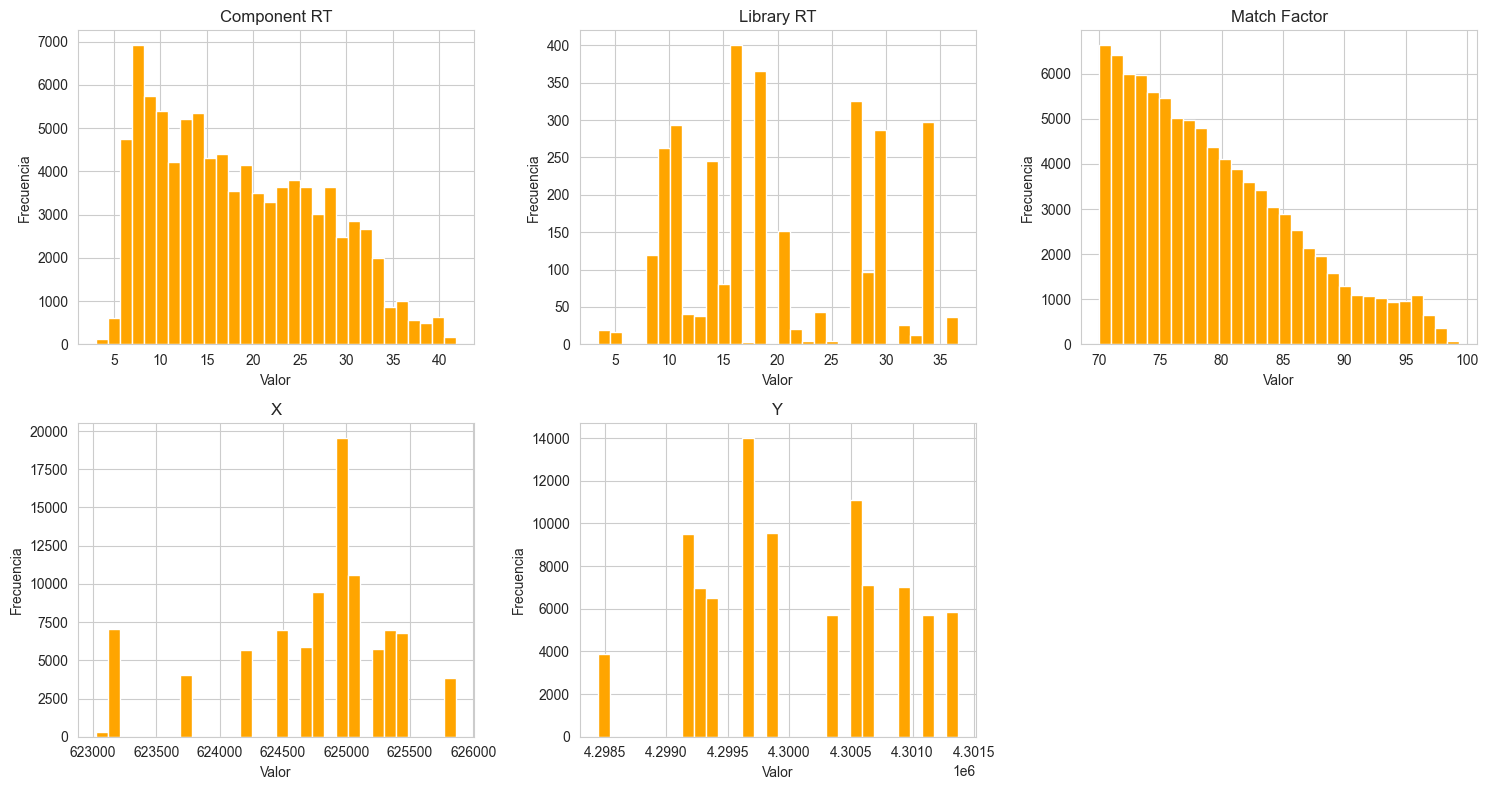

In [21]:
# Definir dimensiones de la malla
ncols = 3
nrows = (len(num_vars) + ncols - 1) // ncols  # Redondeo hacia arriba

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    axes[i].hist(df_petrola[var].dropna(), bins=30, color='orange', edgecolor='white')
    axes[i].set_title(var)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

# Eliminar ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<div style="border: 2px solid white; padding: 15px; border-radius: 5px;">

***Conclusiones del gráfico***:

* Vemos que la **moda del match factor** es 70% y no tenemos casi muestras con valores superiores a 95%, lo cual tiene sentido.  
* En cuanto a la **posición (X, Y)**, tenemos 10 valores distintos totales, pero 11 estaciones, por lo que alguna de las estaciones tiene que compartir posiciones X o Y.

</div>


In [22]:
# Cual es el compuesto con mayor Indice de Coincidencia (Match Factor)?
top_match_factor = (
    df_petrola
    .groupby('Compound Name', observed=False)
    .agg(
        Media_Match_Factor=('Match Factor', 'mean'),
        Num_Muestras=('Match Factor', 'count')
    )
    .reset_index()
    .sort_values(by='Media_Match_Factor', ascending=False)
)
top_match_factor

,Compound Name,Media_Match_Factor,Num_Muestras
6121,"Ethylene glycol, dinitrate",97.891805,2
1266,1H-Benzotriazole,97.659254,3
4308,Benalaxyl,97.486223,1
6925,Monopropyl carbonotrithioate,96.555397,1
5661,Diazinon,95.962075,1
...,...,...,...
4689,"Benzoic acid, 2-iodo-",70.002884,1
9235,"p-Methoxybenzoic acid, 2-bromo-4-fluorophenyl ...",70.002701,1
5776,"Disulfide, methyl 1-methyl-1-(methylthio)propyl",70.002024,1
3249,4-(6-Methoxy-3-methyl-2-benzofuranyl)-4-phenyl...,70.001649,1


## 3.3 Estudio de variables categoricas

In [23]:
for var in cat_vars:
    print(df_petrola[var].value_counts(dropna=False))
    print("-"*50)

Compound Name
1-Decanol, 2-hexyl-                                                                                    3419
Dodecane, 1-iodo-                                                                                      2637
Heneicosane                                                                                            2443
Cyclononasiloxane, octadecamethyl-                                                                     1840
Hexadecane                                                                                             1256
                                                                                                       ... 
2-Chloroethyl palmitate                                                                                   1
1H-Indene, octahydro-2,3a,4-trimethyl-2-(1-methylethyl)-, (2.alpha.,3a.beta.,4.beta.,7a.beta.)-(+)-       1
Heptadecanoic acid                                                                                        1
Eicosanoic aci

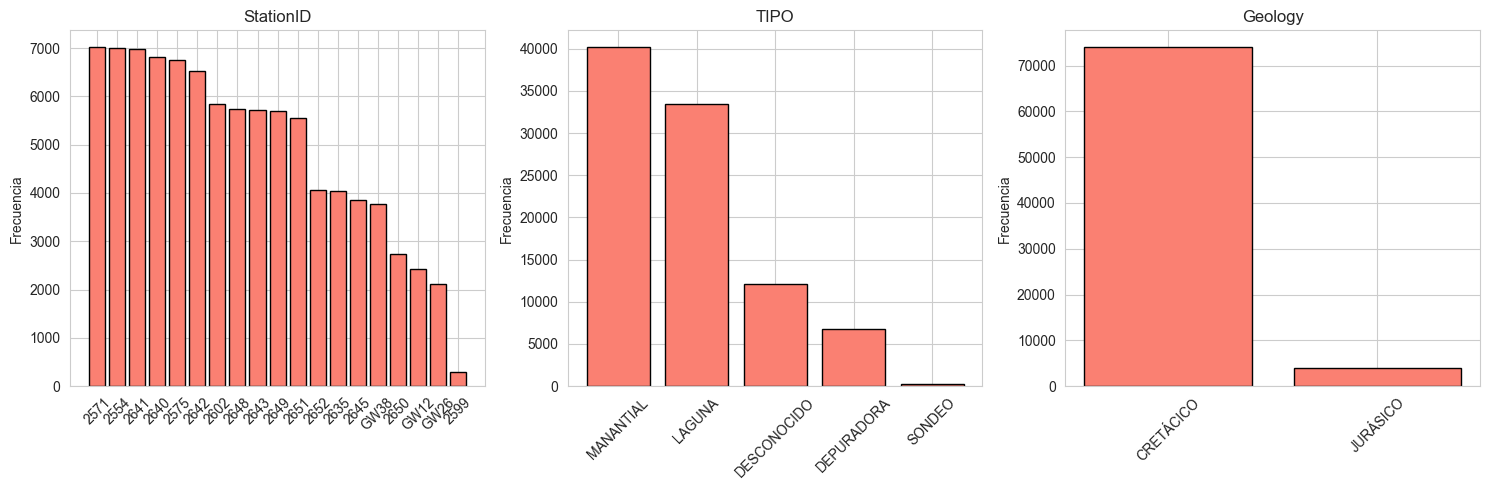

In [24]:
# Filtramos las categoricas con valores unicos menores a 50, por temas de representación en gráficas
cat_vars_filtered = [col for col in cat_vars if df_petrola[col].nunique() < 50]
n = len(cat_vars_filtered)

# Configurar dimensiones de la malla
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 5))
axes = axes.flatten()

for i, var in enumerate(cat_vars_filtered):
    counts = df_petrola[var].value_counts().sort_values(ascending=False)
    axes[i].bar(counts.index.astype(str), counts.values, color='salmon', edgecolor='black')
    axes[i].set_title(var)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos si sobran
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

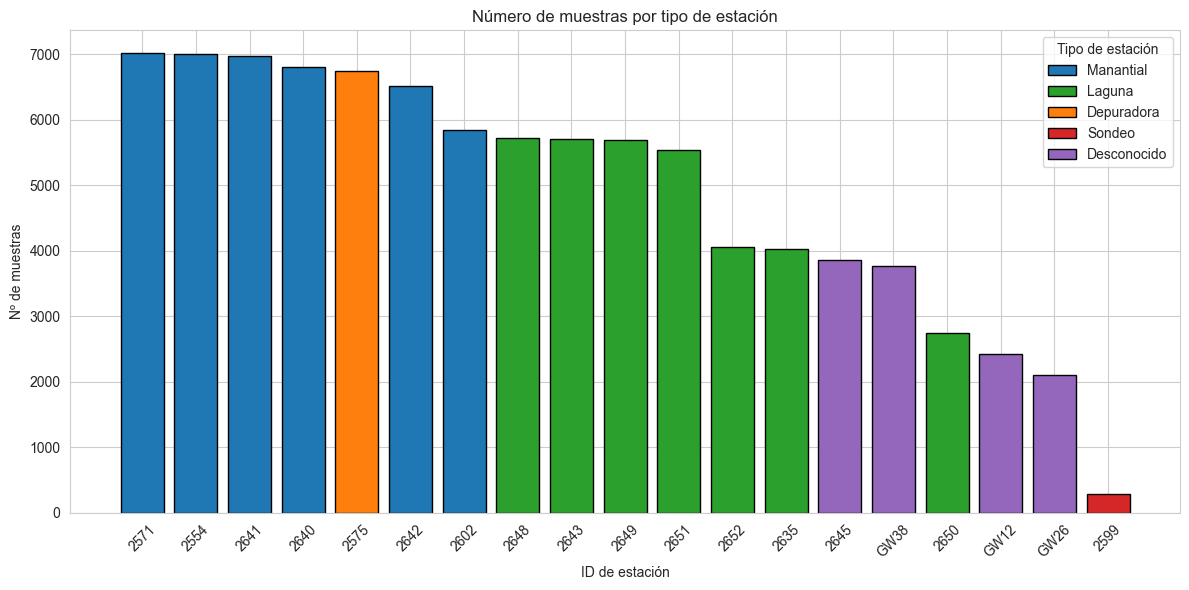

In [25]:
counts = df_petrola['StationID'].value_counts().sort_values(ascending=False)
station_types = df_petrola[['StationID', 'TIPO']].drop_duplicates().set_index('StationID')

# Asignamos un color a cada tipo de estación
color_map = {
    'MANANTIAL': '#1f77b4',
    'LAGUNA': '#2ca02c',
    'DEPURADORA': '#ff7f0e',
    'SONDEO': '#d62728',
    'DESCONOCIDO': '#9467bd'
}
bar_colors = [color_map.get(station_types.loc[sid, 'TIPO'], 'gray') for sid in counts.index]

# Creamos la grafica
plt.figure(figsize=(12, 6))
plt.bar(counts.index.astype(str), counts.values, color=bar_colors, edgecolor='black')
plt.title('Número de muestras por tipo de estación')
plt.ylabel('Nº de muestras')
plt.xlabel('ID de estación')
plt.xticks(rotation=45)

legend_elements = [
    Patch(facecolor=color, edgecolor='black', label=tipo.capitalize()) 
    for tipo, color in color_map.items()
]

# Mostramos la gráfica
plt.legend(handles=legend_elements, title='Tipo de estación', loc='upper right')
plt.tight_layout()
plt.show()

<div style="border: 2px solid white; padding: 15px; border-radius: 5px;">

***Conclusiones del gráfico:***
* La variable `StationID` está bastante balanceada, excepto por el valor **2599**, del cual apenas tenemos muestras tomadas por esa estación.  
* El resto de variables están **muy desbalanceadas** en sus valores, por ejemplo `TIPO` (muy desbalanceada hacia el valor Manantial) o `GEOLOGY` (muy desbalanceada hacia **CRETÁCICO**).  
* Solo existe una unica estación de tipo sondeo (2599), con muy pocas muestras.


</div>

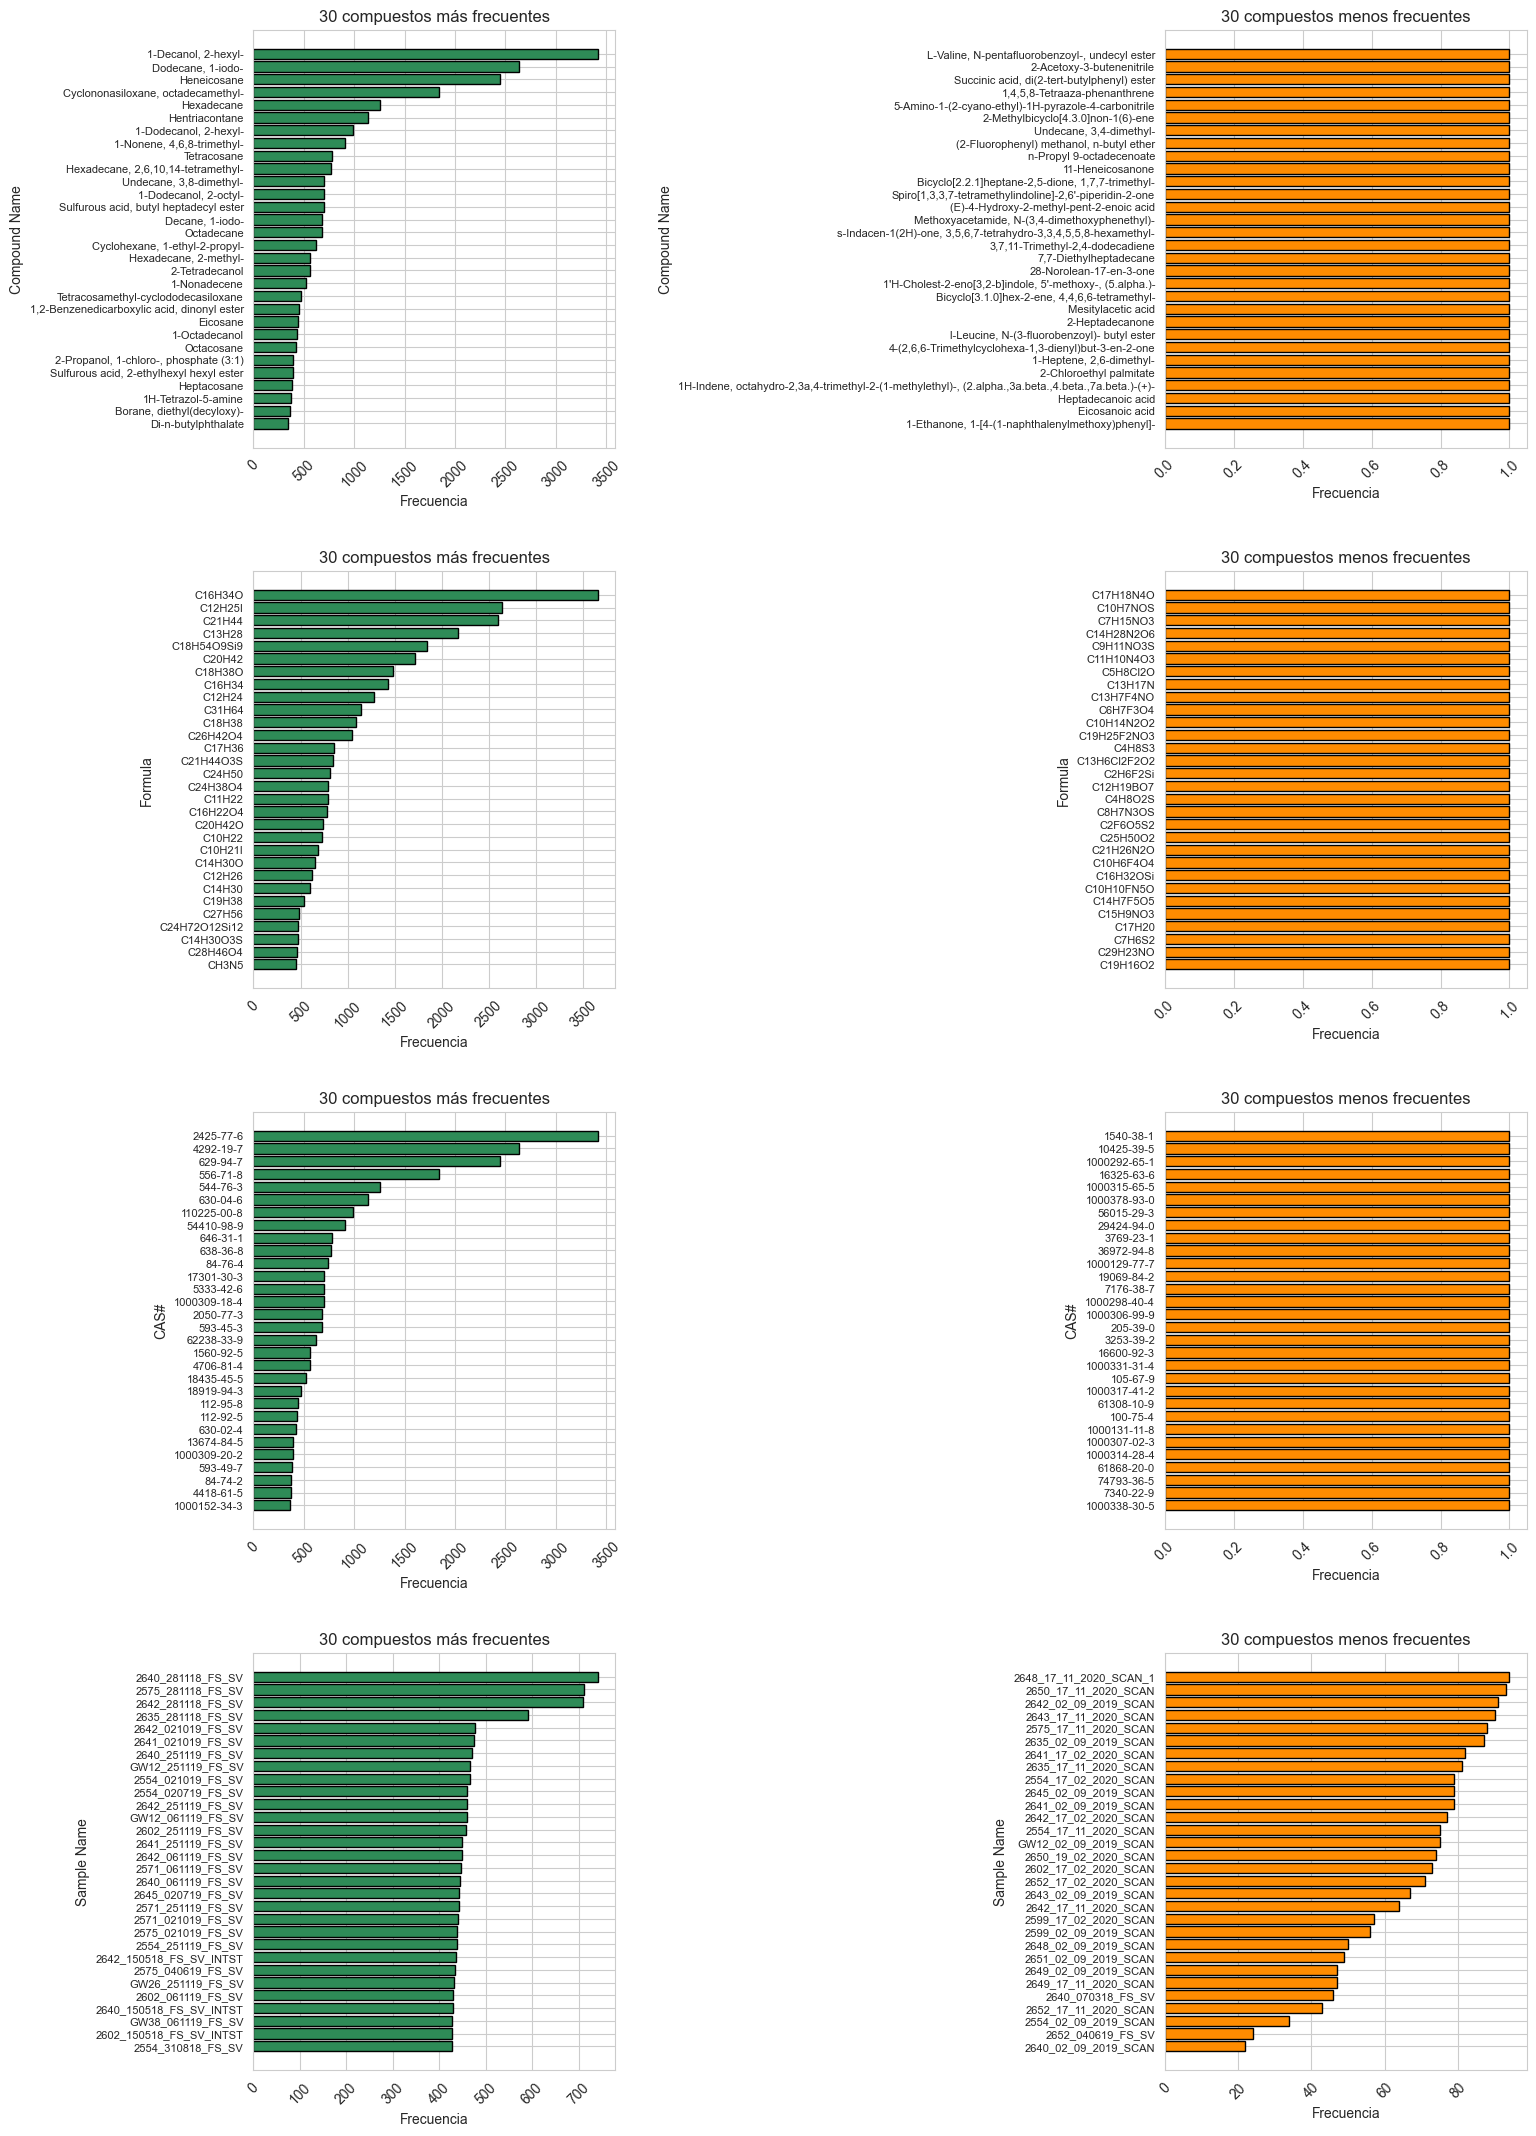

In [26]:
# Filtramos las categoricas con 50 o mas valores unicos distintos
cat_vars_high_count = [col for col in cat_vars if df_petrola[col].nunique() >= 50]

# Creamos la malla
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))  # Aumento la altura de la figura
axes = axes.flatten()

# Iteramos sobre las columnas y las posiciones de la malla
for i, col in enumerate(cat_vars_high_count):
    value_counts = df_petrola[col].value_counts()
    
    top_30 = value_counts.head(30)
    bottom_30 = value_counts.tail(30)

    # --- Top 30 mas frecuentes
    axes[2*i].barh(top_30.index, top_30.values, color='seagreen', edgecolor='black')
    axes[2*i].set_xlabel('Frecuencia')
    axes[2*i].set_ylabel(col)
    axes[2*i].set_title(f'30 compuestos más frecuentes')
    axes[2*i].invert_yaxis()
    axes[2*i].tick_params(axis='y', labelsize=8) 
    axes[2*i].tick_params(axis='x', labelrotation=45)  

    # --- Top 30 menos frecuentes
    axes[2*i+1].barh(bottom_30.index, bottom_30.values, color='darkorange', edgecolor='black')
    axes[2*i+1].set_xlabel('Frecuencia')
    axes[2*i+1].set_ylabel(col)
    axes[2*i+1].set_title(f'30 compuestos menos frecuentes')
    axes[2*i+1].invert_yaxis()
    axes[2*i+1].tick_params(axis='y', labelsize=8) 
    axes[2*i+1].tick_params(axis='x', labelrotation=45) 

# Ajuste del layout
plt.tight_layout(pad=3.0)
plt.show()

<div style="border: 2px solid white; padding: 15px; border-radius: 5px;">

***Conclusiones del gráfico:***
* El compuesto más frecuente con diferencia es: **'1-Decanol, 2-hexyl'** y su fórmula **'C16H34O'**. 
* Se observa una **gran diversidad de compuestos detectados**. El compuesto más frecuente aparece aproximadamente **2.000 veces** sobre un total de **60.000 muestras**, lo que indica que **ningún compuesto domina claramente** el conjunto de datos.   
* Tenemos muchos compuestos que solo han sido detectados **una única vez**, como se puede apreciar en las gráficas de la derecha.  
* `Compound Name`, `CAS` y `formula` son básicamente la **misma gráfica con distinto nombre**, ya que son formas de referirse al mismo elemento: un compuesto químico.

</div>

### Formula vs Compound Name

Durante el desarrollo he observado el siguiente comportamiento, y es que tenemos mas de 9.000 valores distintos para el nombre de un compuesto organico (Compound Name), pero aproximadamente 3500 formulaciones diferentes (Formula), por lo que si o si está ocurriendo que VARIAS compuestos estan siendo asignados a LA MISMA formula. Esto se puede ver con el siguiente código:

In [27]:
# Contador de Formula y Compound Name
print(f"Tenemos un total de {len(df_petrola['Compound Name'].unique())} nombres de compuestos y solo {len(df_petrola['Formula'].unique())} formulaciones diferentes.")

Tenemos un total de 9313 nombres de compuestos y solo 4240 formulaciones diferentes.


In [28]:
# Agrupar por fórmula y contar cuántos nombres distintos hay por cada una
formulas_con_varios_nombres = (
    df_petrola
    .groupby('Formula')['Compound Name']
    .nunique()
    .reset_index(name='Compuestos Asociados')
)

# Filtrar solo aquellas fórmulas con más de un nombre
formulas_multiples = formulas_con_varios_nombres[formulas_con_varios_nombres['Compuestos Asociados'] > 1]

# Mostrar el resultado ordenado por cantidad de nombres distintos
formulas_multiples = formulas_multiples.sort_values(by='Compuestos Asociados', ascending=False)

# Mostrar
formulas_multiples

,Formula,Compuestos Asociados
864,C13H28,56
140,C10H20,53
630,C12H24,48
3827,C8H16,46
4079,C9H18,43
...,...,...
1837,C18H25ClO4,2
1854,C18H29F7O2,2
1858,C18H30FN,2
1861,C18H30O2,2


In [29]:
# Compound Names asociados a la formula C13H28
df_petrola[df_petrola['Formula']=='C13H28']['Compound Name'].unique()

array(['Dodecane, 5-methyl-', 'Decane, 2,3,6-trimethyl-',
       'Nonane, 5-methyl-5-propyl-', 'Undecane, 5,5-dimethyl-',
       'Undecane, 4,7-dimethyl-', 'Decane, 5-ethyl-5-methyl-',
       'Dodecane, 2-methyl-', 'Undecane, 3,8-dimethyl-',
       'Undecane, 2,10-dimethyl-', 'Decane, 3-ethyl-3-methyl-',
       'Undecane, 2,8-dimethyl-', 'Undecane, 6,6-dimethyl-',
       'Undecane, 3,5-dimethyl-', 'Undecane, 2,4-dimethyl-',
       'Undecane, 4,4-dimethyl-', 'Undecane, 3,9-dimethyl-',
       'Undecane, 2,5-dimethyl-', 'Undecane, 3,7-dimethyl-',
       'Undecane, 2,9-dimethyl-', 'Decane, 3,3,5-trimethyl-',
       'Decane, 6-ethyl-2-methyl-', 'Nonane, 3-methyl-5-propyl-',
       'Nonane, 2-methyl-5-propyl-', 'Nonane, 5-(2-methylpropyl)-',
       'Decane, 2,3,8-trimethyl-', 'Undecane, 4,8-dimethyl-',
       'Decane, 2,3,7-trimethyl-', 'Dodecane, 4-methyl-',
       'Decane, 3,3,6-trimethyl-', 'Undecane, 2,7-dimethyl-',
       'Nonane, 5-butyl-', 'Decane, 2,8,8-trimethyl-',
       'Decane, 2

<div style="border: 2px solid white; padding: 15px; border-radius: 5px;">

***Conclusiones del estudio:***
* 1191 de las formulas de nuestra base de datos tienen mas de un compuesto asociado.
* Algunas de ellas tienen mas de 30 compuestos asociados a una única formula.
* Esto puede parecer raro, pero tras investigarlo, se ha descubierto que es una práctica bastante normal en el ámbito de los compuestos orgánicos y no debería causar ningun problema a la hora de insercción ni consultas de nuestra base de datos.
* Está bien haberse percatado de este comportamiento y lo podremos tener en cuenta para el futuro, usando como identificador de los compuestos la variable CAS en lugar de Nombre o formula.

</div>

## 3.3 Estudio de variables temporales

### 3.3.1 Promedio de mtach factor de los 3 compuestos más frecuentes en el tiempo (Mes y Fecha)

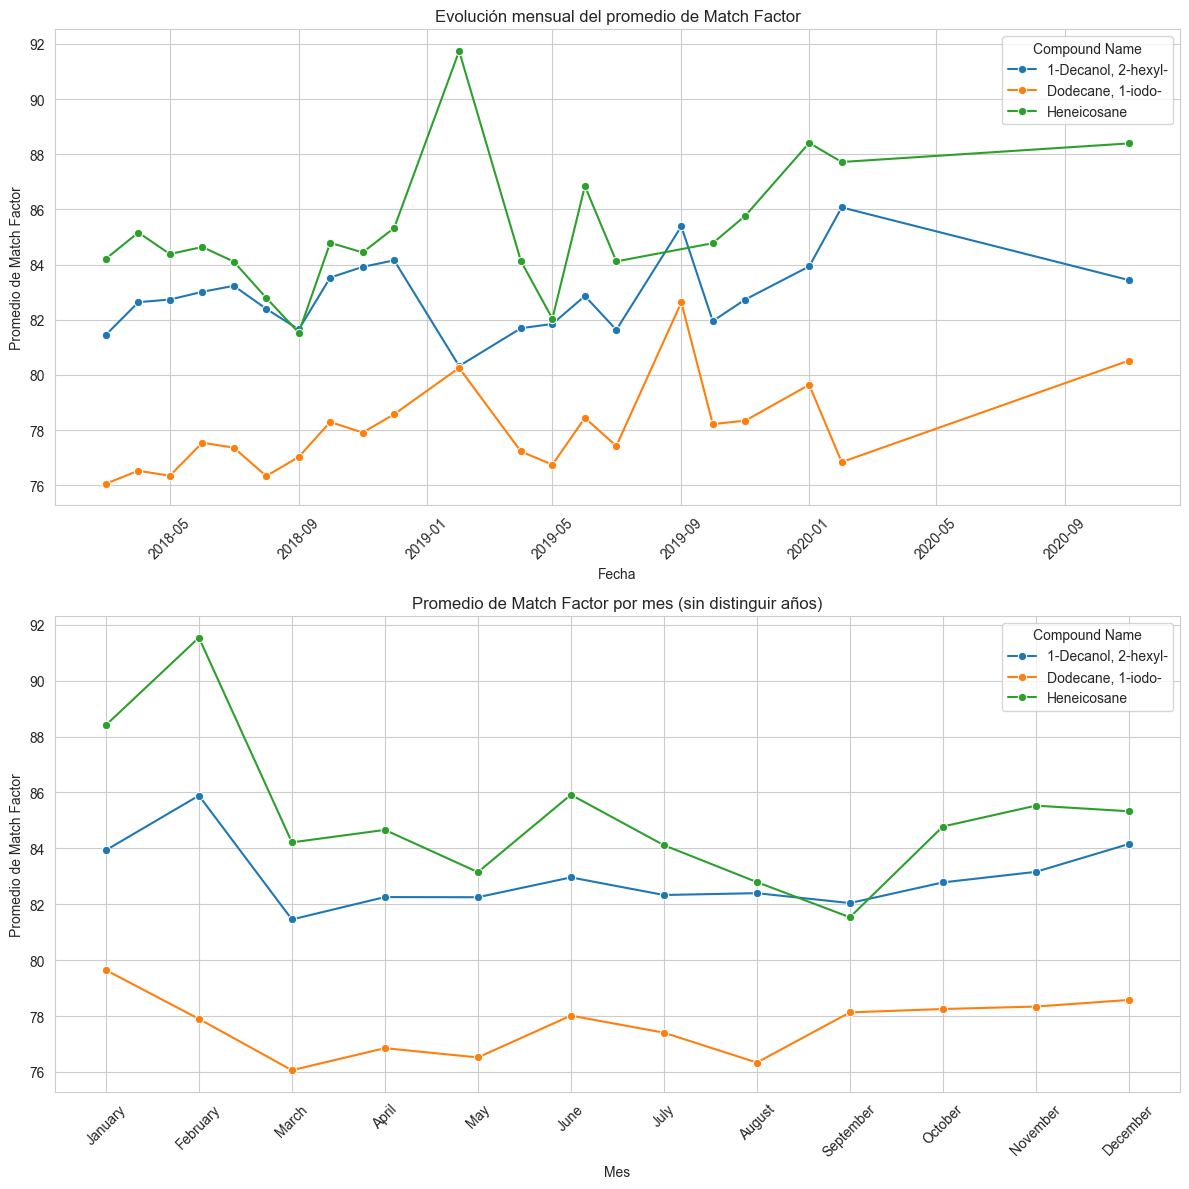

In [30]:
# Aseguramos que 'Date' sea datetime
df_petrola['Date'] = pd.to_datetime(df_petrola['Date'])

# Filtramos por los 3 compuestos más frecuentes
top_3_compuestos = (
    df_petrola['Compound Name']
    .value_counts()
    .head(3)
    .index
    .tolist()
)
df_top = df_petrola[df_petrola['Compound Name'].isin(top_3_compuestos)].copy()

# 3. Creamos columnas extra para saber en que mes y año se tomó la muestra (y poder filtrar y agrupar)
df_top['year_month'] = df_top['Date'].dt.to_period('M').dt.to_timestamp()
df_top['month'] = df_top['Date'].dt.month_name()

# Orden de los meses
ordered_months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_top['month'] = pd.Categorical(df_top['month'], categories=ordered_months, ordered=True)



# Dataframe del promedio de Match Factor por fecha especifica
promedio_mensual = (
    df_top
    .groupby(['year_month', 'Compound Name'], observed=False)
    ['Match Factor']
    .mean()
    .reset_index()
    .sort_values(by='year_month')
)

# b) Dataframe de promedio de Match Factor por mes 
promedio_por_mes = (
    df_top
    .groupby(['month', 'Compound Name'], observed=False)
    ['Match Factor']
    .mean()
    .reset_index()
    .sort_values(by='month')
)

# Creamos la gráfica de 2 filas y 1 columna
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Gráfica 1: Evolución por fecha especifica
sns.lineplot(data=promedio_mensual, x='year_month', y='Match Factor', hue='Compound Name', marker='o', ax=axes[0])
axes[0].set_title('Evolución mensual del promedio de Match Factor')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Promedio de Match Factor')
axes[0].tick_params(axis='x', rotation=45)

# Gráfica 2: Promedio por mes del año
sns.lineplot(data=promedio_por_mes, x='month', y='Match Factor', hue='Compound Name', marker='o', ax=axes[1])
axes[1].set_title('Promedio de Match Factor por mes (sin distinguir años)')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Promedio de Match Factor')
axes[1].tick_params(axis='x', rotation=45)

# Se separan horizontalmente y se dibuja
plt.subplots_adjust(hspace=0.4)
plt.tight_layout()
plt.show()

<div style="border: 2px solid white; padding: 15px; border-radius: 5px;">

***Conclusiones del gráfico:***
* Como vimos en los gráficos anteriores, **Heneicosane** es el **tercer compuesto más frecuente**. Sin embargo, al analizar el **Match Factor promedio por mes**, destaca como el que **mejor calidad de coincidencia** tiene en la mayoría de sus apariciones, **superando a *1-Decanol, 2-hexyl*** en casi todos los meses, **excepto en septiembre y diciembre**.

* En particular, **Heneicosane alcanza un promedio de Match Factor del 92% en febrero**, uno de los valores más altos registrados en todo el año.

* Por otro lado, **Dodecane, 1-iodo**, a pesar de ser el **segundo compuesto más frecuente**, presenta consistentemente **valores de Match Factor más bajos**, situándose **casi siempre por debajo del 80%** durante todos los meses del año.

</div>

### 3.3.2 Evolución de match factor en el tiempo (agrupados todos los compuestos)

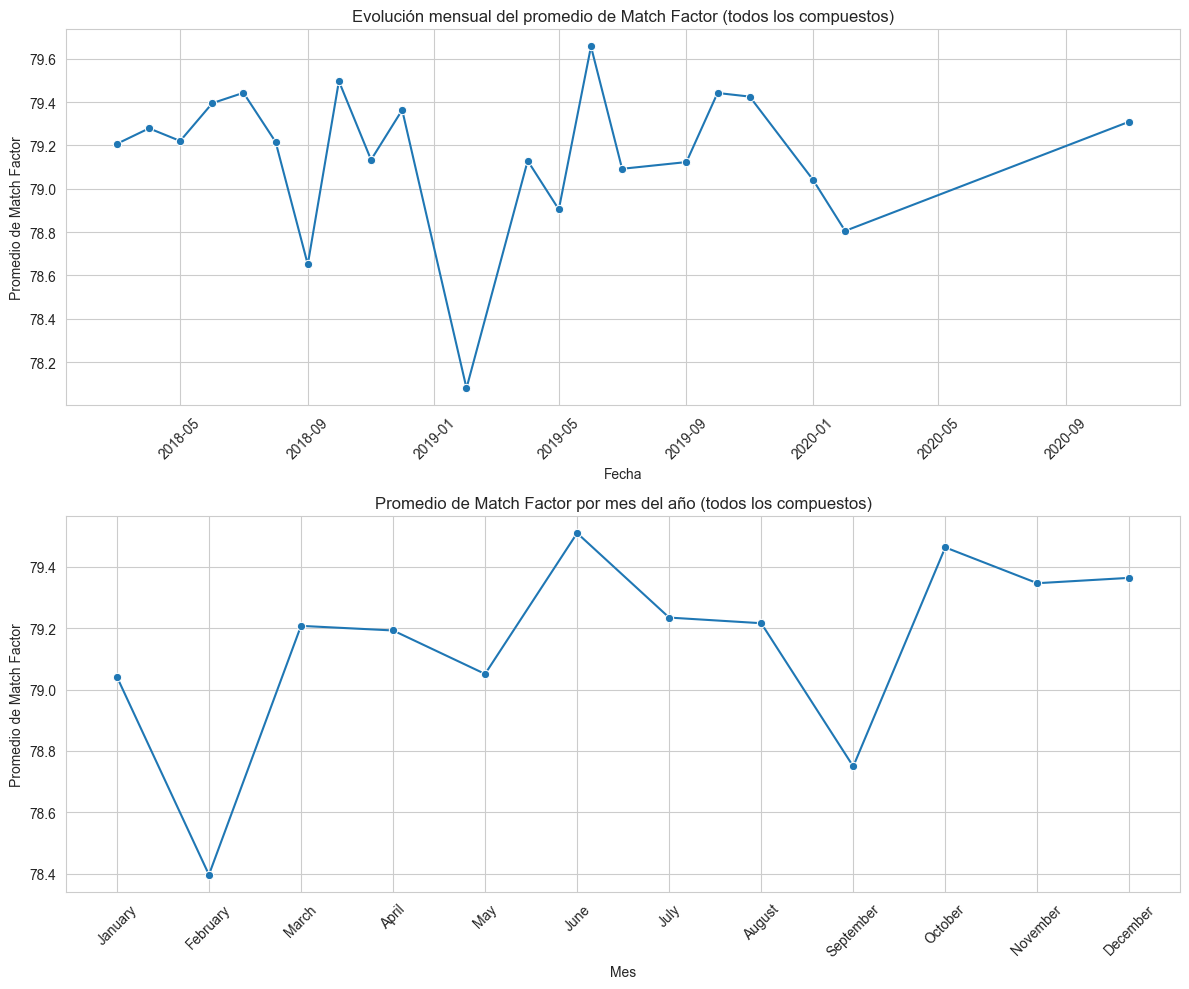

In [31]:
# Crear columnas auxiliares, igual que antes
df_petrola['year_month'] = df_petrola['Date'].dt.to_period('M').dt.to_timestamp()
df_petrola['month'] = df_petrola['Date'].dt.month_name()

# Ordenamos los meses
ordered_months = ['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December']
df_petrola['month'] = pd.Categorical(df_petrola['month'], categories=ordered_months, ordered=True)


# 1. Promedio de Match Factor por año-mes (todos los compuestos)
promedio_mensual = (
    df_petrola
    .groupby('year_month', observed=False)['Match Factor']
    .mean()
    .reset_index()
    .sort_values(by='year_month')
)

# 2. Promedio de Match Factor por mes del año (sin importar el año)
promedio_por_mes = (
    df_petrola
    .groupby('month', observed=False)['Match Factor']
    .mean()
    .reset_index()
    .sort_values(by='month')
)

# Crear la malla
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico 1: Evolución por fecha
sns.lineplot(data=promedio_mensual, x='year_month', y='Match Factor', marker='o', ax=axes[0])
axes[0].set_title('Evolución mensual del promedio de Match Factor (todos los compuestos)')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Promedio de Match Factor')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Promedio por mes del año
sns.lineplot(data=promedio_por_mes, x='month', y='Match Factor', marker='o', ax=axes[1])
axes[1].set_title('Promedio de Match Factor por mes del año (todos los compuestos)')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Promedio de Match Factor')
axes[1].tick_params(axis='x', rotation=45)

# Separación y dibujado
plt.subplots_adjust(hspace=0.4)
plt.tight_layout()
plt.show()

<div style="border: 2px solid white; padding: 15px; border-radius: 5px;">

***Conclusiones del gráfico:***
* Viendo ahora el analisis de Match Factor a lo largo del tiempo para todos los compuestos registrados, vemos que la media baja mucho mas (cerca del 79%), y tiene ligeras variaciones de un 2% de media a lo largo del año.
* En cuanto a las fechas absolutas, tenemos un minimo global de 78% en Marzo de 2019 y un maximo global de algo mas de 80% en Junio 2019.
* En el grafico de los meses vemos que en febrero es cuando se detectan los compuestos menos puros, y va subiendo poco a poco a lo largo del año.

</div>

### 3.3.3 Compuestos mas frecuentes a lo largo del tiempo

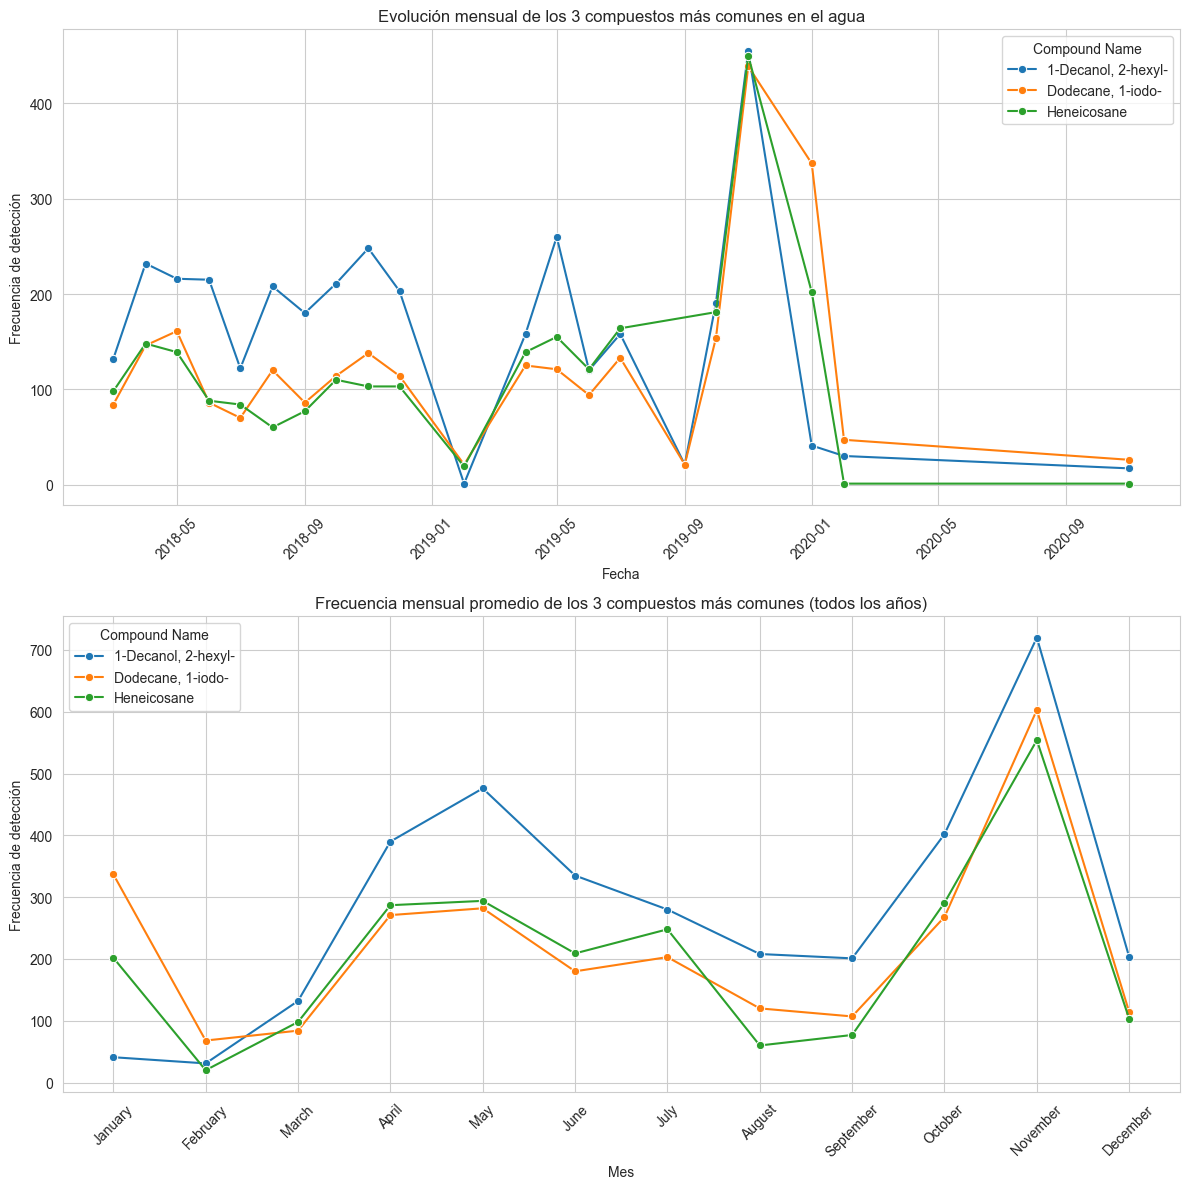

In [32]:
# 1. Obtenemos los 3 compuestos más frecuentes y filtramos el dataframe
top_3_compuestos = (
    df_petrola['Compound Name']
    .value_counts()
    .head(3)
    .index
    .tolist()
)
df_top = df_petrola[df_petrola['Compound Name'].isin(top_3_compuestos)].copy()

# 3. Crear columna año-mes como datetime para la primera gráfica
df_top['year_month'] = df_top['Date'].dt.to_period('M').dt.to_timestamp()

# 4. Agrupar por mes y compuesto
conteo_mensual = (
    df_top
    .groupby(['year_month', 'Compound Name'],  observed=False)
    .size()
    .reset_index(name='count')
    .sort_values(by='year_month')  # Asegura el orden cronológico
)

# Procesamiento de variable mes
df_top['month'] = df_top['Date'].dt.month_name()
ordered_months = ['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December']
df_top['month'] = pd.Categorical(df_top['month'], categories=ordered_months, ordered=True)
conteo_mensual_mes = (
    df_top
    .groupby(['month', 'Compound Name'],  observed=False)
    .size()
    .reset_index(name='count')
    .sort_values(by='month')
)

# Creamos una malla
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Graficar la evolución mensual de los 3 compuestos más comunes
sns.lineplot(data=conteo_mensual, x='year_month', y='count', hue='Compound Name', marker='o', ax=axes[0])
axes[0].set_title('Evolución mensual de los 3 compuestos más comunes en el agua')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Frecuencia de detección')
axes[0].tick_params(axis='x', rotation=45)

# Graficar la frecuencia mensual promedio de los 3 compuestos más comunes
sns.lineplot(data=conteo_mensual_mes, x='month', y='count', hue='Compound Name', marker='o', ax=axes[1])
axes[1].set_title('Frecuencia mensual promedio de los 3 compuestos más comunes (todos los años)')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Frecuencia de detección')
axes[1].tick_params(axis='x', rotation=45)

# Dibujamos
plt.tight_layout()
plt.show()

<div style="border: 2px solid white; padding: 15px; border-radius: 5px;">

***Conclusiones del gráfico:***
* Por motivos de legibilidad, **no es viable mostrar la evolución temporal de todos los compuestos** (hay más de 9000), por lo que, como en análisis anteriores, **nos centraremos en los tres más frecuentes**.

* **Heneicosane**, aunque es el **tercer compuesto más frecuente**, **deja de aparecer en los registros a partir de enero de 2020**.

* Desde el año 2020, se observa que **la frecuencia de *1-Decanol, 2-hexyl*** ha disminuido **drásticamente**, situándose prácticamente al mismo nivel que el segundo más frecuente, **Dodecane, 1-iodo**.

* A lo largo del año, los tres compuestos muestran **patrones de comportamiento muy similares**: incrementan su frecuencia en **primavera**, disminuyen en **verano**, y vuelven a subir alcanzando su punto máximo en los **meses de otoño**.

</div>

## 3.4 Relaciones entre variables

### Numericas vs Numericas

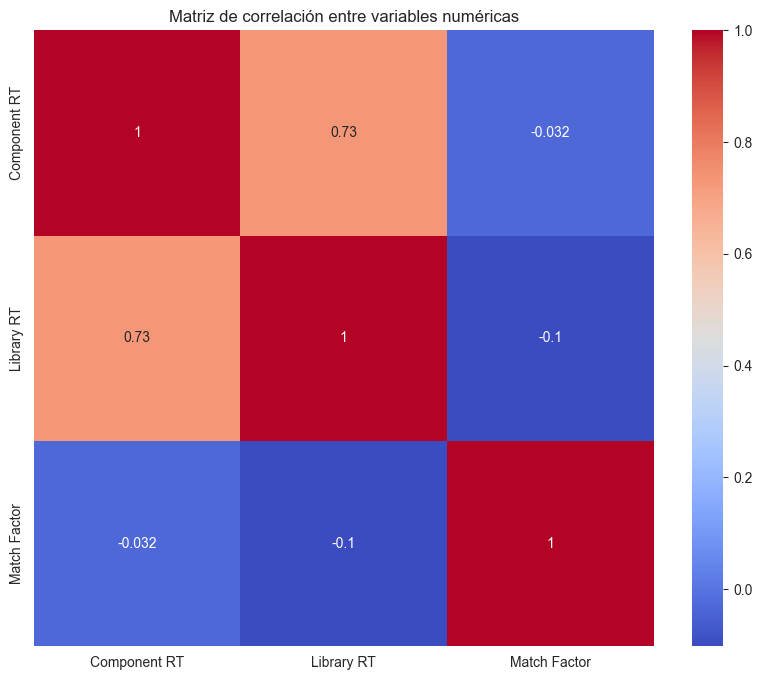

In [33]:
# Mapa de calor de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df_petrola[['Component RT', 'Library RT', 'Match Factor']].corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

<div style="border: 2px solid white; padding: 15px; border-radius: 5px;">

***Conclusiones del gráfico***:

* Quitando la diagonal principal,el resto de variables parecen no estar fuertemente relacionadas.

</div>

### Categoricas vs Categoricas

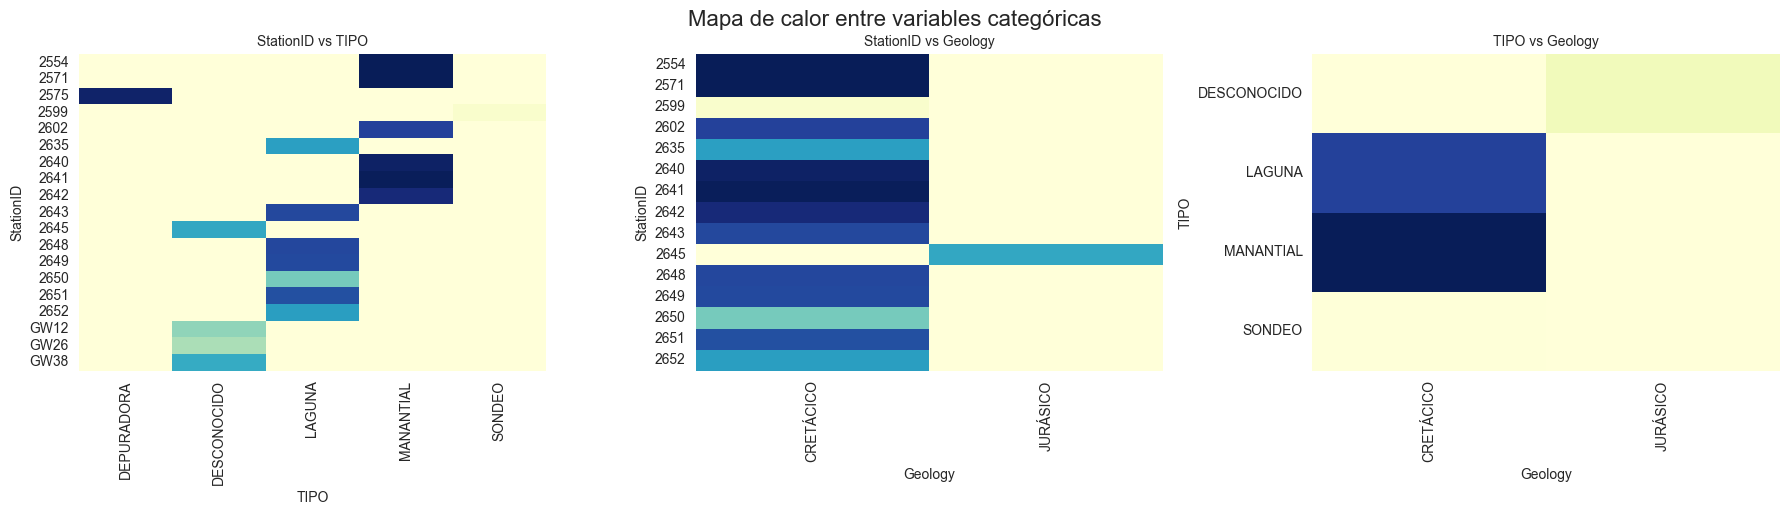

In [40]:
# Número máximo de categorías que se mostrarán por variable (para evitar caos visual)
TOP_N = 10
cat_vars2 = ['StationID', 'TIPO','Geology']

# Creamos todas las combinaciones posibles de pares únicos de variables
cat_pairs = list(combinations(cat_vars2, 2))

# Se calcula el tamaño de la malla, segun el número de pares
n_plots = len(cat_pairs)
n_cols = 3
n_rows = int((n_plots + n_cols - 1) // n_cols)

# Se crea la mallla
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

for idx, (var1, var2) in enumerate(cat_pairs):
    # Se crean cada uno de los mapas de calor
    ct = pd.crosstab(df_petrola[var1], df_petrola[var2])
    sns.heatmap(ct, ax=axes[idx], cmap='YlGnBu', annot=False, cbar=False)
    axes[idx].set_title(f'{var1} vs {var2}', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=90)
    axes[idx].tick_params(axis='y', rotation=0)

# Si hay ejes sobrantes en la malla, los quitamos
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Mapa de calor entre variables categóricas", fontsize=16, y=1.02)
plt.show()

<div style="border: 2px solid white; padding: 15px; border-radius: 5px;">

***Conclusiones del gráfico***:

* La unica estación que tiene Geology = Jurasico es la id = 2645.
* La mayoria de las variables son binarias y sus heatmap son casi identicos, por lo que no podemos detectar relaciones particulares. Ademas de tener muchos de sus valores perdidos.

</div>

###  Numericas vs Categoricas (solo algunas)

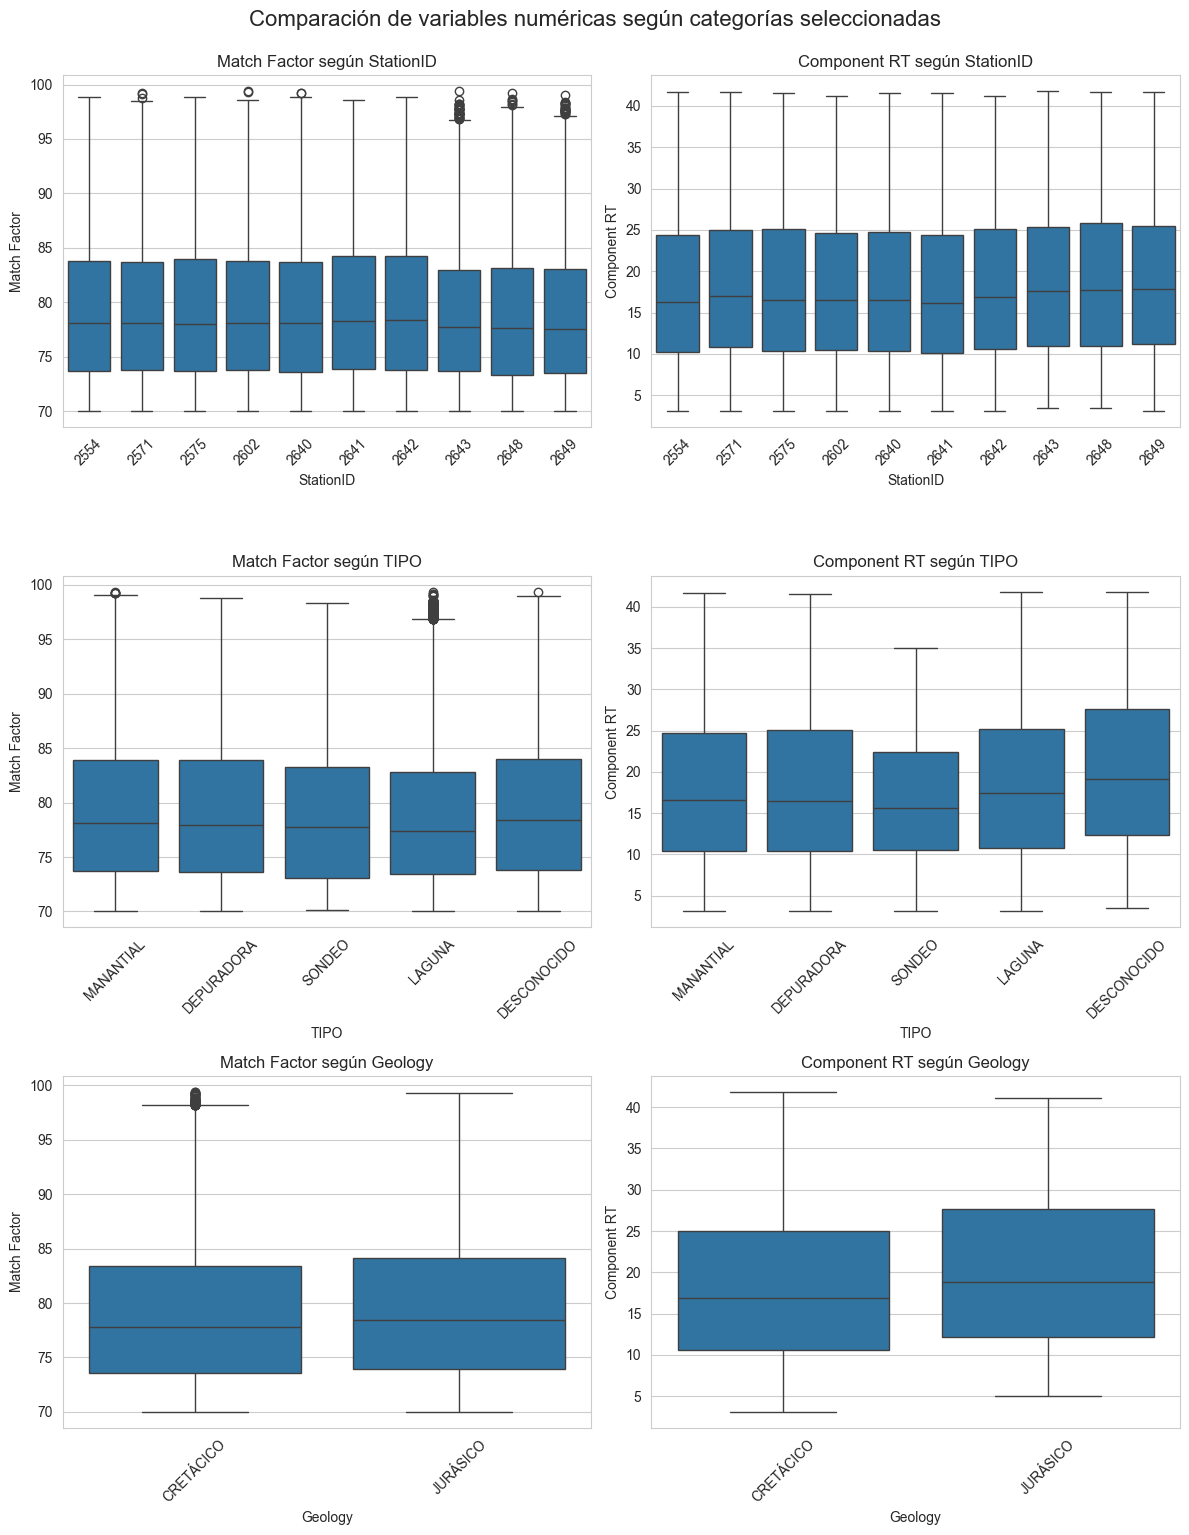

In [44]:
# Parámetros (por motivos de legibilidad, solo mostramos los TOP_N primeros valores de las variables grandes)
TOP_N = 10
num_interesting = ['Match Factor', 'Component RT']
cat_interesting = ['StationID', 'TIPO', 'Geology']

# Creamos los pares de variables y número de gráficas necesarias
pairs = [(cat, num) for cat in cat_interesting for num in num_interesting]
n_plots = len(pairs)
n_cols = 2
n_rows = int((n_plots + n_cols - 1) // n_cols)

# Creamos la malla
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

for idx, (cat, num) in enumerate(pairs):
    # Se crean los boxplots para cada par de variables
    ax = axes[idx]

    top_cats = df_petrola[cat].value_counts().nlargest(TOP_N).index
    df_temp = df_petrola[df_petrola[cat].isin(top_cats)]

    sns.boxplot(data=df_temp, x=cat, y=num, ax=ax)
    ax.set_title(f'{num} según {cat}')
    ax.tick_params(axis='x', rotation=45)

# Eliminamos gráficas sobrantes
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Comparación de variables numéricas según categorías seleccionadas', fontsize=16, y=1.02)
plt.show()

<div style="border: 2px solid white; padding: 15px; border-radius: 5px;">

***Conclusiones del gráfico***:
* La variable match_factor presenta un rango de valores prácticamente constante entre todas las categorías analizadas. Por ejemplo, a pesar de la gran diferencia en número de estaciones y muestras entre los tipos de geología cretácica y jurásica, sus distribuciones de match_factor son casi idénticas.
* Un comportamiento similar se observa en la variable component_rt, que apenas varía entre categorías. 
</div>


## 3.5 Conclusiones del EDA

- Tras la unión de los dos dataframes, tenemos bastantes variables que han perdido potencial, presentando muchos valores NaN.
- La mayoría de las variables numéricas están muy desbalanceadas; algunas solo tienen un único valor distinto a NaN.
- La mayoría de las variables categóricas son booleanas y están desbalanceadas hacia el valor `False`.
- Tenemos un rango de frecuencia de compuestos de  hasta 9300.
- El compuesto que más aparece es **1-Decanol, 2-hexyl**.
- Tenemos fórmulas con varios nombres de compuestos diferentes asociados.
- La mayoría de los compuestos muestreados no llegan al 90% de **Match Factor**, siendo la moda 70%.
- La pureza (**Match Factor**) de los compuestos varía según la estación del año, aunque muy poco (en un rango del 2%), siendo la máxima en octubre.
- Hay más frecuencia de compuestos en el agua en primavera y otoño (aunque también puede ser que este dato esté alterado por la frecuencia de muestreos en el tiempo).
- No existen (o al menos no se ha encontrado) relaciones fuertes entre variables.
